### E3: ENSO correlations

Evaluate correlations of AIMIP monthly variables with the specified SST ENSO index.

In [1]:
import xarray as xr
import numpy as np
from datetime import datetime
import os
from dask.diagnostics import ProgressBar
from cartopy import crs as ccrs
from matplotlib import pyplot as plt

from aimip_data_utils import (
    AIMIP_EXPERIMENT_SUBMISSIONS,
    EVALUATION_VARIABLES,
    ERA5_1DEG,
    EVALUATION_PRESSURE_LEVELS,
    open_aimip_data,
    add_latlon_to_dlesym,
    regrid_dataset,
    transfer_attrs,
    convert_tdas_to_huss,
    compute_error,
    compute_rms,
    load_gfdl_am4_from_cmip6_gcs,
    GFDL_CM4_AMIP_ZARR_TEMPLATE,
    CATEGORICAL_COLORS,
)
from enso_index import NINO34_INDEX_ARRAY as nino34

In [2]:
TRAINING_DATES = ('1979-01-01', '2014-12-31')
TEST_DATES = ('2015-01-01', '2024-12-31')
LATITUDE_LIMITS = (-87.5, 87.5) # avoid regridding artifacts at the poles
OUTDIR = os.environ.get('AIMIP_FIGURES_DIR', './figures')
CACHE_DIR = os.environ.get('AIMIP_CACHE_DIR', './cached')
os.makedirs(OUTDIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)
RESET_CACHE = False
RESTORE_CACHE = True

In [3]:
def compute_enso_coefficient(
    ds: xr.Dataset,
    index: xr.DataArray,
    eval_variables: list[str],
    keep_vars: list[str] | None = None,
    index_dim_name: str='time',
) -> xr.Dataset:
    if keep_vars is None:
        keep_vars = []
    index_ds_coord = index.interp({index_dim_name: ds[index_dim_name]})
    index_ds_coord = index_ds_coord - index_ds_coord.mean(index_dim_name)
    ds_eval_vars = [var for var in eval_vars if var in ds.data_vars]
    cov = (index_ds_coord * ds[ds_eval_vars]).mean(index_dim_name)
    index_var = index_ds_coord.var(index_dim_name)
    coeff = cov / index_var
    coeff = transfer_attrs(ds, coeff)
    for var in ds_eval_vars:
        existing_long_name, existing_units = (
            coeff[var].attrs.get('long_name', var),
            coeff[var].attrs.get('units', 'unknown_units'), 
        )
        coeff[var] = coeff[var].assign_attrs({
            'long_name': f"{existing_long_name} ENSO coefficient",
            'units': f"{existing_units} K-1",
        })
    for keep_var in keep_vars:
        if keep_var in ds.data_vars:
            coeff[keep_var] = ds[keep_var]
    return coeff

## How to run this notebook

This notebook runs in one of two modes, set by `RESET_CACHE` / `RESTORE_CACHE` in the cell above.

**Reproduce the manuscript figures from the bundled cache** — the default (`RESTORE_CACHE = True`, `RESET_CACHE = False`). No raw data is needed: run the setup cells above, then the **Restore minimal cache** cell, then the cells in the **Manuscript figures** section. You can skip the **Data loading & processing** section and the intermediate diagnostic cells — they read the full (~1.8 TB) raw dataset.

**Regenerate the cache from the raw dataset** (`RESET_CACHE = True`, `RESTORE_CACHE = False`). Download the full submissions (see the repo `README.md` → Data) and run every cell top to bottom; the minimal cache is rewritten from scratch.

## Data loading & processing

*Skip this section when using the bundled cache.* These cells read the full raw dataset and are only needed to regenerate the cache (`RESET_CACHE = True`).

In [ ]:
monthly_data, _ = open_aimip_data(
    AIMIP_EXPERIMENT_SUBMISSIONS,
    EVALUATION_VARIABLES,
    table='Amon',
)

In [ ]:
for experiment_submission_name, dataset in monthly_data.items():
    print(f"Checking {experiment_submission_name} for huss/tdas.")
    monthly_data[experiment_submission_name] = convert_tdas_to_huss(dataset)

In [ ]:
# open CMIP6 GFDL CM4 data
other_variables = ['lat', 'lat_bnds', 'lon', 'lon_bnds']
gfdl_cm4_monthly_1deg, missing_paths = load_gfdl_am4_from_cmip6_gcs(
    GFDL_CM4_AMIP_ZARR_TEMPLATE,
    EVALUATION_VARIABLES,
    other_variables,
)
# Conflicting native calendars (Julian vs Proleptic Gregorian) between CMIP6 and AIMIP respectively
# But doesn't matter since it's monthly averaged data and we're not weighting by month length
# when doing time reductions (maybe we should be?)
# So just convert it to standard calendar
gfdl_cm4_monthly_1deg = gfdl_cm4_monthly_1deg.assign_coords(
    {
        'time': gfdl_cm4_monthly_1deg.time.astype('datetime64[ns]') 
    }
)
gfdl_cm4_monthly_1deg = gfdl_cm4_monthly_1deg.expand_dims({'realization': [1]})
monthly_data['GFDL-CM4'] = gfdl_cm4_monthly_1deg

In [ ]:
# specific fixes

# add coordinates to DLESyM
monthly_data['DLESyM'] = add_latlon_to_dlesym(monthly_data['DLESyM'])

# ArchesWeather surface temperature has different units (C)
for experiment_submission in ['ArchesWeather', 'ArchesWeatherGen']:
    monthly_data[experiment_submission]['ts'] = monthly_data[experiment_submission].ts + 273.15

In [ ]:
era5_monthly_1deg, _ = open_aimip_data(
    [ERA5_1DEG],
    EVALUATION_VARIABLES,
    table='Amon',
    n_realizations=1,
)
era5_monthly_1deg = (
    era5_monthly_1deg['ERA5']
    .isel(realization=0).squeeze()
    .drop_vars(['forecast_period', 'originating_centre'])
)
era5_monthly_1deg = convert_tdas_to_huss(era5_monthly_1deg)

In [ ]:
eval_vars = [var.short_name for var in EVALUATION_VARIABLES]

def _months_btwn_inclusive(start, end, fmt='%Y-%m-%d'):
    d1 = datetime.strptime(start, fmt)
    d2 = datetime.strptime(end, fmt)
    return (d2.year - d1.year) * 12 + (d2.month - d1.month) + 1

enso_coeff = {}
for k, v in monthly_data.items():
    print(k)
    coefficient_periods = []
    for time_period_name, time_period in (
        ('training', (TRAINING_DATES[0], TRAINING_DATES[1])),
        ('test', (TEST_DATES[0], TEST_DATES[1])),
        ('all', (TRAINING_DATES[0], TEST_DATES[1])),
    ):
        n_months = _months_btwn_inclusive(*time_period)
        v_period = v.sel(time=slice(*time_period))
        # For GFDL-CM4, propagate any-NaN cells to NaN for the entire time window.
        # CM4's surface pressure varies → some cells are intermittently below-surface;
        # a regression over a partial/intermittent series produces huge noise in the
        # coefficient that dominates the global-mean RMSE.
        if k == 'GFDL-CM4':
            for var in eval_vars:
                if var in v_period.data_vars and 'plev' in v_period[var].dims:
                    below_surface_any = v_period[var].isnull().any('time')
                    v_period = v_period.assign(
                        {var: v_period[var].where(~below_surface_any)}
                    )
        if v_period.sizes['time'] > n_months * 0.85:
            coefficient_periods.append(
                compute_enso_coefficient(
                    v_period,
                    nino34,
                    eval_vars,
                    keep_vars=['lat', 'lon'],
                ).expand_dims({'time_period': [time_period_name]})
            )
    enso_coeff[k] = xr.concat(coefficient_periods, dim='time_period') 

In [ ]:
with ProgressBar():
    enso_coeff = {
        k: v.compute() for k, v in enso_coeff.items()
    }

In [ ]:
era5_monthly_1deg_training = era5_monthly_1deg.sel(time=slice(TRAINING_DATES[0], TRAINING_DATES[1]))
era5_monthly_1deg_test = era5_monthly_1deg.sel(time=slice(TEST_DATES[0], TEST_DATES[1]))
era5_monthly_1deg_all = era5_monthly_1deg.sel(time=slice(TRAINING_DATES[0], TEST_DATES[1]))

enso_coeff_era5_1deg = xr.concat(
    [


        compute_enso_coefficient(
            era5_monthly_1deg_training,
            nino34,
            eval_vars,
        ).expand_dims({'time_period': ['training']}),
        compute_enso_coefficient(
            era5_monthly_1deg_test,
            nino34,
            eval_vars,
        ).expand_dims({'time_period': ['test']}),
        compute_enso_coefficient(
            era5_monthly_1deg_all,
            nino34,
            eval_vars,
        ).expand_dims({'time_period': ['all']}),
    ],
    dim='time_period',
)

In [ ]:
with ProgressBar():
    enso_coeff_era5_1deg = enso_coeff_era5_1deg.compute()

In [ ]:
regridded_1deg_enso_coeffs = []
experiment_submissions_1_deg = list(enso_coeff.keys())
experiment_submissions_1_deg.remove('NeuralGCM') # don't evaluate 2.8 deg at 1 deg
for experiment_submission_name in experiment_submissions_1_deg:
    print(experiment_submission_name)
    if experiment_submission_name not in ['cBottle1.3', 'DLESyM']:
        regridder_kwargs = dict(method='conservative')
    else: 
        # for cBottle HEALPix grid, need to use nearest-neighbor unstructured interpolation
        regridder_kwargs = dict(locstream_in=True, method='nearest_s2d')
    # destination grid is 1deg ERA5
    destination_grid = (
        era5_monthly_1deg
        .isel(time=0)
        .sel(lat=slice(*LATITUDE_LIMITS))
        [['lat', 'lon', 'lat_bnds', 'lon_bnds']]
    )
    regridded_1deg_enso_coeff = regrid_dataset(
        enso_coeff[experiment_submission_name],
        destination_grid,
        sample_dims=['realization', 'time_period'],
        **regridder_kwargs
    )
    regridded_1deg_enso_coeffs.append(
        regridded_1deg_enso_coeff.expand_dims(
            {
                'experiment_submission': [experiment_submission_name]
            }
        )
    )
regridded_1deg_enso_coeffs = xr.concat(regridded_1deg_enso_coeffs, dim='experiment_submission', join='outer', combine_attrs='override')
# Propagate model variable attrs to ERA5 so 2.8deg regrid inherits them.
enso_coeff_era5_1deg = transfer_attrs(regridded_1deg_enso_coeffs, enso_coeff_era5_1deg)
# Mask ERA5 pressure-level data to AM4's valid (above-surface) domain.
# AM4 leaves below-surface grid cells as NaN; ERA5 artificially infills them.
# Masking ERA5 here ensures all downstream computations (regridding, trends, global
# means) are over the same physical domain as AM4, making metrics comparable.
_am4_1deg = regridded_1deg_enso_coeffs.sel(experiment_submission='GFDL-CM4', drop=True)
for _var in enso_coeff_era5_1deg.data_vars:
    if _var in _am4_1deg.data_vars and 'plev' in enso_coeff_era5_1deg[_var].dims:
        _non_spatial = [d for d in _am4_1deg[_var].dims if d not in ('lat', 'lon', 'plev')]
        _below_surface = _am4_1deg[_var].isnull().all(_non_spatial)
        enso_coeff_era5_1deg[_var] = enso_coeff_era5_1deg[_var].where(~_below_surface)

In [ ]:
regridded_2p8deg_enso_coeffs = []
experiment_submissions_2p8deg = list(enso_coeff.keys())
experiment_submissions_2p8deg.remove('NeuralGCM-HRD') # don't evaluate 1 deg at 2.8 deg
neural_gcm_ind = experiment_submissions_2p8deg.index('NeuralGCM')
experiment_submissions_2p8deg.pop(neural_gcm_ind) # target grid; will put back later
for experiment_submission_name in experiment_submissions_2p8deg:
    print(experiment_submission_name)
    if experiment_submission_name not in ['cBottle1.3', 'DLESyM']:
        regridder_kwargs = dict(method='conservative')
    else: 
        # for cBottle HEALPix grid, need to use nearest-neighbor unstructured interpolation
        regridder_kwargs = dict(locstream_in=True, method='nearest_s2d')
    # destination grid is 2.8 deg NeuralGCM
    destination_grid = (
        monthly_data['NeuralGCM']
        .isel(time=0, realization=0)
        .sel(lat=slice(*LATITUDE_LIMITS))
        [['lat', 'lon', 'lat_bnds', 'lon_bnds']]
    )
    regridded_2p8deg_enso_coeff = regrid_dataset(
        enso_coeff[experiment_submission_name],
        destination_grid,
        sample_dims=['realization', 'time_period'],
        **regridder_kwargs
    )
    regridded_2p8deg_enso_coeffs.append(
        regridded_2p8deg_enso_coeff.expand_dims(
            {
                'experiment_submission': [experiment_submission_name]
            }
        )
    )
regridded_2p8deg_enso_coeffs.append(
    enso_coeff['NeuralGCM'].sel(lat=slice(*LATITUDE_LIMITS)).expand_dims(
        {
            'experiment_submission': ['NeuralGCM']
        }
    )
)
regridded_2p8deg_enso_coeffs = xr.concat(regridded_2p8deg_enso_coeffs, dim='experiment_submission', join='outer', combine_attrs='override')
experiment_submissions_2p8deg.insert(neural_gcm_ind, 'NeuralGCM')
regridded_2p8deg_enso_coeffs = regridded_2p8deg_enso_coeffs.sel(experiment_submission=experiment_submissions_2p8deg)

In [ ]:
# regrid ERA5 to 2.8 deg NeuralGCM grid
destination_grid_era5 = (
    monthly_data['NeuralGCM']
    .isel(time=0, realization=0)
    .sel(lat=slice(*LATITUDE_LIMITS))
    [['lat', 'lon', 'lat_bnds', 'lon_bnds']]
)
regridded_2p8deg_enso_coeff_era5 = regrid_dataset(
    enso_coeff_era5_1deg,
    destination_grid_era5,
    sample_dims=['time_period'],
    method='conservative',
)

In [ ]:
if RESET_CACHE:
    # Reduce to plot-ready products before caching. The manuscript figures need only:
    #   - ENSO-coefficient ERROR + ERA5 maps for tas/pr (realization 0)  -> map figures
    #   - the scalar ENSO-coefficient RMSE tables (all vars/levels)       -> bar figures
    # The full gridded coefficient fields are just an intermediate cache and are NOT saved.
    enso_coeff_error_1deg = compute_error(
        regridded_1deg_enso_coeffs,
        enso_coeff_era5_1deg,
    ).sel(experiment_submission=regridded_1deg_enso_coeffs.experiment_submission, plev=EVALUATION_PRESSURE_LEVELS)
    enso_coeff_error_2p8deg = compute_error(
        regridded_2p8deg_enso_coeffs,
        regridded_2p8deg_enso_coeff_era5,
    ).sel(experiment_submission=regridded_2p8deg_enso_coeffs.experiment_submission, plev=EVALUATION_PRESSURE_LEVELS)
    enso_coeff_rmse_1deg = compute_rms(enso_coeff_error_1deg)
    enso_coeff_rmse_2p8deg = compute_rms(enso_coeff_error_2p8deg)

    MANUSCRIPT_MAP_VARS = ['tas', 'pr']
    _to_cache = {
        'enso_coeff_error_map_1deg.nc': enso_coeff_error_1deg[MANUSCRIPT_MAP_VARS].isel(realization=[0]),
        'enso_coeff_era5_map_1deg.nc': enso_coeff_era5_1deg[MANUSCRIPT_MAP_VARS],
        'enso_coeff_error_map_2p8deg.nc': enso_coeff_error_2p8deg[MANUSCRIPT_MAP_VARS].isel(realization=[0]),
        'enso_coeff_era5_map_2p8deg.nc': regridded_2p8deg_enso_coeff_era5[MANUSCRIPT_MAP_VARS],
        'enso_coeff_rmse_1deg.nc': enso_coeff_rmse_1deg,
        'enso_coeff_rmse_2p8deg.nc': enso_coeff_rmse_2p8deg,
    }
    for _fname, _ds in _to_cache.items():
        _p = os.path.join(CACHE_DIR, _fname)
        try:
            os.remove(_p)
        except FileNotFoundError:
            pass
        _ds.to_netcdf(_p)
    print("Cache updated (reduced manuscript-figure inputs).")

## Restore minimal cache

*Start here when using the bundled cache* (`RESTORE_CACHE = True`). This loads the reduced, plot-ready inputs for the manuscript figures. The cells between here and **Manuscript figures** produce supplementary diagnostics; some require the full dataset, so skip them in cache mode.

In [4]:
if RESTORE_CACHE:
    print("Cache restored (reduced manuscript-figure inputs).")
    enso_coeff_error_1deg = xr.open_dataset(os.path.join(CACHE_DIR, 'enso_coeff_error_map_1deg.nc'))
    enso_coeff_era5_1deg = xr.open_dataset(os.path.join(CACHE_DIR, 'enso_coeff_era5_map_1deg.nc'))
    enso_coeff_error_2p8deg = xr.open_dataset(os.path.join(CACHE_DIR, 'enso_coeff_error_map_2p8deg.nc'))
    regridded_2p8deg_enso_coeff_era5 = xr.open_dataset(os.path.join(CACHE_DIR, 'enso_coeff_era5_map_2p8deg.nc'))
    enso_coeff_rmse_1deg = xr.open_dataset(os.path.join(CACHE_DIR, 'enso_coeff_rmse_1deg.nc'))
    enso_coeff_rmse_2p8deg = xr.open_dataset(os.path.join(CACHE_DIR, 'enso_coeff_rmse_2p8deg.nc'))

Cache restored (reduced manuscript-figure inputs).


In [5]:
def get_varname_indexer(var: str) -> tuple[str, dict[str, float]]:
    if var in ['tas', 'ts', 'pr', 'huss']:
        return var, {}
    elif var.startswith('Q'):
        return 'hus', {'plev': [85000.]}
    elif var.startswith('U'):
        return 'ua', {'plev': [85000.]}
    elif var.startswith('V'):
        return 'va', {'plev': [85000.]}
    elif var.startswith('AT'):
        if var.endswith('100'):
            return 'ta', {'plev': [10000.]}
        else:
            return 'ta', {'plev': [85000.]}
      
map_vars = ['tas', 'ts', 'pr', 'huss', 'AT850', 'AT100', 'Q850', 'U850', 'V850']

## Supplementary diagnostics

*Skip this section when using the bundled cache.* These non-manuscript diagnostics require the full dataset (they use variables/fields not kept in the minimal cache).

In [ ]:
combined_mean_1deg_enso_coeffs = xr.concat(
    [
        regridded_1deg_enso_coeffs.isel(realization=0),
        enso_coeff_era5_1deg.drop_vars('realization').expand_dims(
            {
                'experiment_submission': ['ERA5']
            }
        )
    ],
    dim='experiment_submission',
)

time_period='training'
for var in map_vars:
    varname, indexer = get_varname_indexer(var)
    plottable = combined_mean_1deg_enso_coeffs.sel(time_period=time_period, **indexer)[varname]
    vmin = plottable.quantile(0.02)
    fg = plottable.plot(
        col='experiment_submission', cmap='RdBu_r', vmin=vmin, vmax=-vmin,
        subplot_kws=dict(projection=ccrs.Robinson()),
        transform=ccrs.PlateCarree(),
        figsize=(16, 3),
        cbar_kwargs=dict(
            label=(
                f'{enso_coeff_error_1deg[varname].attrs.get("long_name", varname)} '
                f'ENSO coefficient [{enso_coeff_error_1deg[varname].attrs.get("units", "-")}]'
            ),
            orientation='horizontal',
            aspect=50,
        ),
    )
    fg.set_titles('{value}')
    fg.fig.patch.set_alpha(0.0)
    fg.fig.savefig(os.path.join(OUTDIR, f'ENSO_coeff_1deg_map_{time_period}_{var}.png'), bbox_inches='tight')

In [ ]:
time_period='training'
for var in map_vars:
    varname, indexer = get_varname_indexer(var)
    plottable = enso_coeff_error_1deg.isel(realization=0).sel(time_period=time_period, **indexer)[varname]
    vmin = plottable.quantile(0.02)
    fg = plottable.plot(
        col='experiment_submission', cmap='RdBu_r', vmin=vmin, vmax=-vmin,
        subplot_kws=dict(projection=ccrs.Robinson()),
        transform=ccrs.PlateCarree(),
        figsize=(16, 3),
        cbar_kwargs=dict(
            label=(
                f'{enso_coeff_error_1deg[varname].attrs.get("long_name", varname)} '
                f'ENSO coefficient error [{enso_coeff_error_1deg[varname].attrs.get("units", "-")}]'
            ),
            orientation='horizontal',
            aspect=50,
        ),
    )
    fg.set_titles('{value}')
    fg.fig.patch.set_alpha(0.0)
    fg.fig.savefig(os.path.join(OUTDIR, f'ENSO_coeff_1deg_error_map_{time_period}_{var}.png'), bbox_inches='tight')

In [ ]:
combined_mean_2p8deg_enso_coeffs = xr.concat(
    [
        regridded_2p8deg_enso_coeffs.isel(realization=0),
        regridded_2p8deg_enso_coeff_era5.drop_vars('realization').expand_dims(
            {
                'experiment_submission': ['ERA5']
            }
        )
    ],
    dim='experiment_submission',
)

time_period='training'
for var in map_vars:
    varname, indexer = get_varname_indexer(var)
    plottable = combined_mean_2p8deg_enso_coeffs.sel(time_period=time_period, **indexer)[varname]
    vmin = plottable.quantile(0.02)
    fg = plottable.plot(
        col='experiment_submission', cmap='RdBu_r', vmin=vmin, vmax=-vmin,
        subplot_kws=dict(projection=ccrs.Robinson()),
        transform=ccrs.PlateCarree(),
        figsize=(16, 3),
        cbar_kwargs=dict(
            label=(
                f'{enso_coeff_error_2p8deg[varname].attrs.get("long_name", varname)} '
                f'ENSO coefficient [{enso_coeff_error_2p8deg[varname].attrs.get("units", "-")}]'
            ),
            orientation='horizontal',
            aspect=50,
        ),
    )
    fg.set_titles('{value}')
    fg.fig.patch.set_alpha(0.0)
    fg.fig.savefig(os.path.join(OUTDIR, f'ENSO_coeff_2p8deg_map_{time_period}_{var}.png'), bbox_inches='tight')

In [ ]:
time_period='training'
for var in map_vars:
    varname, indexer = get_varname_indexer(var)
    plottable = enso_coeff_error_2p8deg.isel(realization=0).sel(time_period=time_period, **indexer)[varname]
    vmin = plottable.quantile(0.02)
    fg = plottable.plot(
        col='experiment_submission', cmap='RdBu_r', vmin=vmin, vmax=-vmin,
        subplot_kws=dict(projection=ccrs.Robinson()),
        transform=ccrs.PlateCarree(),
        figsize=(16, 3),
        cbar_kwargs=dict(
            label=(
                f'{enso_coeff_error_2p8deg[varname].attrs.get("long_name", varname)} '
                f'ENSO coefficient error [{enso_coeff_error_2p8deg[varname].attrs.get("units", "-")}]'
            ),
            orientation='horizontal',
            aspect=50,
        ),
    )
    fg.set_titles('{value}')
    fg.fig.patch.set_alpha(0.0)
    fg.fig.savefig(os.path.join(OUTDIR, f'ENSO_coeff_2p8deg_error_map_{time_period}_{var}.png'), bbox_inches='tight')

In [ ]:
for varname in [varname for varname in enso_coeff_rmse_1deg.data_vars if "plev" in enso_coeff_rmse_1deg[varname].dims]:
    fig, ax = plt.subplots(figsize=(12, 5))
    enso_coeff_rmse_1deg_var = enso_coeff_rmse_1deg.sel(time_period=['training', 'all', 'test'])[varname].rename('RMSB').transpose('time_period', 'plev', 'experiment_submission', 'realization')
    lowest, median, highest = (
        enso_coeff_rmse_1deg_var.min('realization').to_dataframe().unstack(),
        enso_coeff_rmse_1deg_var.median('realization').to_dataframe().unstack(),
        enso_coeff_rmse_1deg_var.max('realization').to_dataframe().unstack(),
    )
    median.plot.bar(width=0.9, 
        ax=ax,
        legend=False,
        color=CATEGORICAL_COLORS,
        yerr=np.concat([(median - lowest).values.T[:, None, :], (highest - median).values.T[:, None, :]], axis=1),
        capsize=0,
        error_kw=dict(elinewidth=0.5),
    )
    ax.legend(enso_coeff_rmse_1deg.experiment_submission.values, fontsize='small')
    ymax = median.max().mean()
    ax.set_ylim([0, ymax])
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    ax.fill_between([1 * xlim[1] / 3, 2 * xlim[1] / 3], [0, 0], [ylim[1], ylim[1]], color='k', alpha=0.075, zorder=-1)
    ax.fill_between([2 * xlim[1] / 3, xlim[1]], [0, 0], [ylim[1], ylim[1]], color='#d9d9d9', zorder=-2)
    ax.set_xticklabels([str(round(ind[1]/100)) for ind in median.index])
    ax.set_xlabel('pressure level [hPa]')
    ax.set_ylabel(f"{enso_coeff_rmse_1deg[varname].attrs.get('long_name', varname)} RMS error [{enso_coeff_rmse_1deg[varname].attrs.get('units', '-')}]")
    ax.grid(axis='y')
    fig.patch.set_alpha(0.0)
    fig.savefig(os.path.join(OUTDIR, f"ENSO_coefficient_1deg_RMSE_{varname}.png"), bbox_inches='tight')

In [ ]:
surface_vars = [var for var in enso_coeff_rmse_1deg.data_vars if "plev" not in enso_coeff_rmse_1deg[var].coords]
fig, axes = plt.subplots(ncols=int(np.ceil(len(surface_vars) / 2)), nrows=2, figsize=(15, 10), sharex=True, sharey=False, gridspec_kw={'wspace': 0.55, 'hspace': 0.5})
for ax, varname in zip(axes.flatten(), surface_vars):
    enso_coeff_rmse_1deg_var = enso_coeff_rmse_1deg.sel(time_period=['training', 'all', 'test'])[varname].transpose('time_period', 'experiment_submission', 'realization')
    lowest, median, highest = (
        enso_coeff_rmse_1deg_var.min('realization').to_dataframe().unstack(),
        enso_coeff_rmse_1deg_var.median('realization').to_dataframe().unstack(),
        enso_coeff_rmse_1deg_var.max('realization').to_dataframe().unstack(),
    )
    median.plot.bar(width=0.9, 
        ax=ax,
        legend=False, 
        color=CATEGORICAL_COLORS,
        yerr=np.concat([(median - lowest).values.T[:, None, :], (highest - median).values.T[:, None, :]], axis=1),
        capsize=0,
        error_kw=dict(elinewidth=0.5),
    )
    if ax is axes.flatten()[-2]:
        axes.flatten()[-1].set_axis_off()
        ax.legend(enso_coeff_rmse_1deg.experiment_submission.values, fontsize='small', bbox_to_anchor=(1.05, 1), loc='upper left')
    ymax = median.max().max()
    ax.set_ylim([0, ymax])
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    ax.fill_between([1 * xlim[1] / 3, 2 * xlim[1] / 3], [0, 0], [ylim[1], ylim[1]], color='k', alpha=0.075, zorder=-1)
    ax.fill_between([2 * xlim[1] / 3, xlim[1]], [0, 0], [ylim[1], ylim[1]], color='#d9d9d9', zorder=-2)
    ax.set_xticklabels([ind for ind in median.index])
    ax.set_xlabel('')
    ax.set_ylabel(f"{enso_coeff_rmse_1deg[varname].attrs.get('long_name', varname)} RMSE [{enso_coeff_rmse_1deg[varname].attrs.get('units', '-')}]")
    ax.grid(axis='y')
    fig.patch.set_alpha(0.0)
    fig.savefig(os.path.join(OUTDIR, "ENSO_coefficient_1deg_RMSE_surface_variables.png"), bbox_inches='tight')

In [ ]:
for varname in [varname for varname in enso_coeff_rmse_2p8deg.data_vars if "plev" in enso_coeff_rmse_2p8deg[varname].dims]:
    fig, ax = plt.subplots(figsize=(12, 5))
    enso_coeff_rmse_2p8deg_var = enso_coeff_rmse_2p8deg.sel(time_period=['training', 'all', 'test'])[varname].rename('RMSB').transpose('time_period', 'plev', 'experiment_submission', 'realization')
    lowest, median, highest = (
        enso_coeff_rmse_2p8deg_var.min('realization').to_dataframe().unstack(),
        enso_coeff_rmse_2p8deg_var.median('realization').to_dataframe().unstack(),
        enso_coeff_rmse_2p8deg_var.max('realization').to_dataframe().unstack(),
    )
    median.plot.bar(width=0.9, 
        ax=ax,
        legend=False,
        color=CATEGORICAL_COLORS,
        yerr=np.concat([(median - lowest).values.T[:, None, :], (highest - median).values.T[:, None, :]], axis=1),
        capsize=0,
        error_kw=dict(elinewidth=0.5),
    )
    ax.legend(enso_coeff_rmse_2p8deg.experiment_submission.values, fontsize='small')
    ymax = median.max().mean()
    ax.set_ylim([0, ymax])
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    ax.fill_between([1 * xlim[1] / 3, 2 * xlim[1] / 3], [0, 0], [ylim[1], ylim[1]], color='k', alpha=0.075, zorder=-1)
    ax.fill_between([2 * xlim[1] / 3, xlim[1]], [0, 0], [ylim[1], ylim[1]], color='#d9d9d9', zorder=-2)
    ax.set_xticklabels([str(round(ind[1]/100)) for ind in median.index])
    ax.set_xlabel('pressure level [hPa]')
    ax.set_ylabel(f"{enso_coeff_rmse_2p8deg[varname].attrs.get('long_name', varname)} RMS error [{enso_coeff_rmse_2p8deg[varname].attrs.get('units', '-')}]")
    ax.grid(axis='y')
    fig.patch.set_alpha(0.0)
    fig.savefig(os.path.join(OUTDIR, f"ENSO_coefficient_2p8deg_RMSE_{varname}.png"), bbox_inches='tight')

In [ ]:
surface_vars = [var for var in enso_coeff_rmse_2p8deg.data_vars if "plev" not in enso_coeff_rmse_2p8deg[var].coords]
fig, axes = plt.subplots(ncols=int(np.ceil(len(surface_vars) / 2)), nrows=2, figsize=(15, 10), sharex=True, sharey=False, gridspec_kw={'wspace': 0.55, 'hspace': 0.5})
for ax, varname in zip(axes.flatten(), surface_vars):
    enso_coeff_rmse_2p8deg_var = enso_coeff_rmse_2p8deg.sel(time_period=['training', 'all', 'test'])[varname].transpose('time_period', 'experiment_submission', 'realization')
    lowest, median, highest = (
        enso_coeff_rmse_2p8deg_var.min('realization').to_dataframe().unstack(),
        enso_coeff_rmse_2p8deg_var.median('realization').to_dataframe().unstack(),
        enso_coeff_rmse_2p8deg_var.max('realization').to_dataframe().unstack(),
    )
    median.plot.bar(width=0.9, 
        ax=ax,
        legend=False,
        color=CATEGORICAL_COLORS,
        yerr=np.concat([(median - lowest).values.T[:, None, :], (highest - median).values.T[:, None, :]], axis=1),
        capsize=0,
        error_kw=dict(elinewidth=0.5),
    )
    if ax is axes.flatten()[-2]:
        axes.flatten()[-1].set_axis_off()
        ax.legend(enso_coeff_rmse_2p8deg.experiment_submission.values, fontsize='small', bbox_to_anchor=(1.05, 1), loc='upper left')
    ymax = median.max().max()
    ax.set_ylim([0, ymax])
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    ax.fill_between([1 * xlim[1] / 3, 2 * xlim[1] / 3], [0, 0], [ylim[1], ylim[1]], color='k', alpha=0.075, zorder=-1)
    ax.fill_between([2 * xlim[1] / 3, xlim[1]], [0, 0], [ylim[1], ylim[1]], color='#d9d9d9', zorder=-2)
    ax.set_xticklabels([ind for ind in median.index])
    ax.set_xlabel('')
    ax.set_ylabel(f"{enso_coeff_rmse_2p8deg[varname].attrs.get('long_name', varname)} RMSE [{enso_coeff_rmse_2p8deg[varname].attrs.get('units', '-')}]")
    ax.grid(axis='y')
    fig.patch.set_alpha(0.0)
    fig.savefig(os.path.join(OUTDIR, "ENSO_coefficient_2p8deg_RMSE_surface_variables.png"), bbox_inches='tight')

## Manuscript Figures

In [6]:
import re
import textwrap
import matplotlib.ticker as mticker

MANUSCRIPT_DIR = os.path.join(OUTDIR, 'manuscript_figures')
os.makedirs(MANUSCRIPT_DIR, exist_ok=True)

MANUSCRIPT_DPI = 300
MANUSCRIPT_FORMAT = 'eps'

# GMD / EGU figure width limits (in inches)
GMD_SINGLE_COL_IN = 84 / 25.4   # 84 mm
GMD_DOUBLE_COL_IN = 174 / 25.4  # 174 mm
GMD_MAX_HEIGHT_IN = 170 / 25.4  # 170 mm — leave room for caption

LABEL_FS = 7

def ms_savefig(fig, name):
    """Save a manuscript figure with consistent settings."""
    path = os.path.join(MANUSCRIPT_DIR, f'{name}.{MANUSCRIPT_FORMAT}')
    fig.savefig(path, dpi=MANUSCRIPT_DPI, format=MANUSCRIPT_FORMAT)
    fig.savefig(os.path.join(MANUSCRIPT_DIR, f'{name}.png'), dpi=MANUSCRIPT_DPI, format='png')
    print(f'Saved {path}')

def fmt_units(u):
    """Convert raw unit strings like 'K K-1' to LaTeX 'K K$^{-1}$'.
    Also strips a dimensionless leading '1 ' (e.g. '1 K-1' -> 'K$^{-1}$').
    """
    u = re.sub(r'^1\s+', '', u)          # drop leading dimensionless '1 '
    return re.sub(r'(\S+)-(\d+)', r'\1$^{-\2}$', u)

Saved ./figures/manuscript_figures/enso_coeff_map_1deg.eps


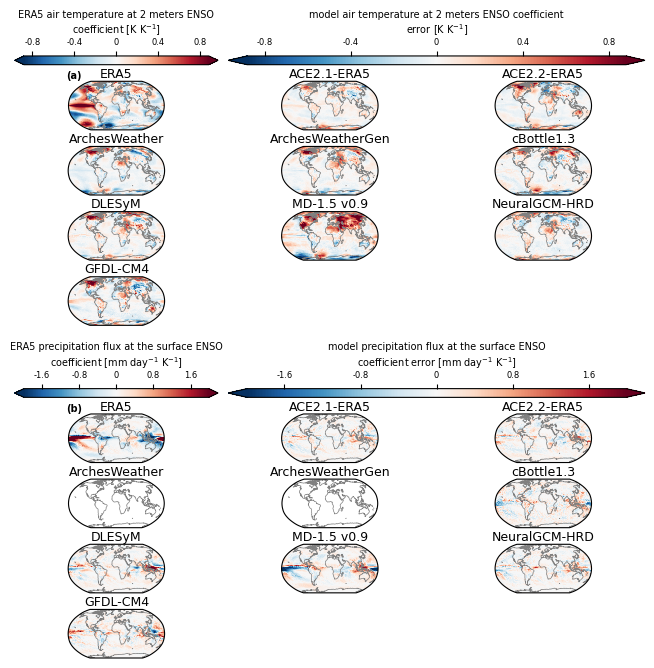

In [7]:
def _model_title(label, width=20):
    """Wrap only at spaces; never break hyphenated tokens mid-word."""
    return textwrap.fill(label, width=width, max_lines=2, break_long_words=False, break_on_hyphens=False)


def plot_enso_coeff_map(enso_coeff_error, enso_coeff_era5, resolution_tag, save_name=None):
    """
    Plot ENSO coefficient maps at a given resolution.

    enso_coeff_error : Dataset with dims (time_period, experiment_submission, [realization,] lat, lon)
    enso_coeff_era5  : Dataset with dims (time_period, [realization,] lat, lon)

    Layout mirrors E2 trend bias maps:
      rows    = CB row + map rows (ERA5 + models in 3-col grid), one block per variable
      columns = 3 (fixed)
    ERA5 and model rows use shared color scale per variable.
    """
    vars_to_plot = ['tas', 'pr']
    exp_names    = list(enso_coeff_error.experiment_submission.values)
    n_cols       = 3
    n_panels     = 1 + len(exp_names)
    n_map_rows   = (n_panels + n_cols - 1) // n_cols

    VAR_SCALE = {'pr': 86400.}
    VAR_UNITS = {
        'tas': r'K K$^{-1}$',
        'pr':  r'mm day$^{-1}$ K$^{-1}$',
    }
    VAR_LONG_NAMES = {
        var: enso_coeff_era5[var].attrs.get('long_name', var).lower().replace('_', ' ').replace('enso coefficient', 'ENSO coefficient')
        for var in vars_to_plot
    }

    # Shared vlim per variable: max of ERA5 and error 98th-percentile abs
    vlim = {}
    for var in vars_to_plot:
        scale = VAR_SCALE.get(var, 1.0)
        era5_da = enso_coeff_era5[var].sel(time_period='training')
        if 'realization' in era5_da.dims:
            era5_da = era5_da.isel(realization=0)
        vlim_era5 = float(np.nanquantile(np.abs(era5_da.values * scale), 0.98))
        err_da = enso_coeff_error[var].isel(realization=0).sel(time_period='training')
        vlim_err = float(np.nanquantile(np.abs(err_da.values * scale), 0.98))
        vlim[var] = max(vlim_era5, vlim_err)

    CB_H  = 0.60
    SEP_H = 0.20
    map_h = (GMD_DOUBLE_COL_IN / n_cols) / 2.1
    height_ratios = [CB_H] + [1.0] * n_map_rows + [SEP_H] + [CB_H] + [1.0] * n_map_rows
    n_gs_rows = len(height_ratios)

    fig_height = min(
        map_h * (sum(height_ratios) + 0.40 * (n_gs_rows - 1)) + 0.3,
        GMD_MAX_HEIGHT_IN,
    )

    fig = plt.figure(figsize=(GMD_DOUBLE_COL_IN, fig_height))
    gs  = fig.add_gridspec(
        nrows=n_gs_rows, ncols=n_cols,
        height_ratios=height_ratios,
        hspace=0.40, wspace=0.05,
    )
    fig.subplots_adjust(left=0.05, right=0.97, top=0.94, bottom=0.01)

    var_gs_offsets = [0, n_map_rows + 1 + 1]
    block_letters  = ['a', 'b']

    for vi, var in enumerate(vars_to_plot):
        scale     = VAR_SCALE.get(var, 1.0)
        units     = VAR_UNITS.get(var, '')
        long_name = VAR_LONG_NAMES.get(var, var)

        gs_offset   = var_gs_offsets[vi]
        cb_gs_row   = gs_offset
        map_gs_rows = list(range(gs_offset + 1, gs_offset + 1 + n_map_rows))

        all_labels = ['ERA5'] + exp_names
        all_axes   = []
        for panel_idx in range(len(all_labels)):
            map_row_idx = panel_idx // n_cols
            col         = panel_idx % n_cols
            ax = fig.add_subplot(
                gs[map_gs_rows[map_row_idx], col], projection=ccrs.Robinson()
            )
            ax.coastlines(color='gray', linewidth=0.5)
            all_axes.append(ax)

        # Plot ERA5 (training period absolute coefficients)
        era5_da = enso_coeff_era5[var].sel(time_period='training')
        if 'realization' in era5_da.dims:
            era5_da = era5_da.isel(realization=0)
        data_era5 = era5_da * scale
        if np.isnan(data_era5.values).all():
            all_axes[0].set_global()
            era5_im = None
        else:
            era5_im = data_era5.plot(
                ax=all_axes[0], transform=ccrs.PlateCarree(),
                cmap='RdBu_r', vmin=-vlim[var], vmax=vlim[var],
                add_colorbar=False, add_labels=False, rasterized=True,
            )

        # Plot model errors (training period)
        model_im = None
        for i, exp in enumerate(exp_names):
            ax   = all_axes[i + 1]
            data = enso_coeff_error[var].isel(realization=0).sel(
                time_period='training', experiment_submission=exp
            ) * scale
            if np.isnan(data.values).all():
                ax.set_global()
            else:
                model_im = data.plot(
                    ax=ax, transform=ccrs.PlateCarree(),
                    cmap='RdBu_r', vmin=-vlim[var], vmax=vlim[var],
                    add_colorbar=False, add_labels=False, rasterized=True,
                )
            ax.set_title('')

        # Panel letter on ERA5 panel; model-name titles on all panels
        for i, (ax, label) in enumerate(zip(all_axes, all_labels)):
            if i == 0:
                ax.text(
                    -0.02, 1.02, f'({block_letters[vi]})',
                    transform=ax.transAxes, fontsize=LABEL_FS, fontweight='bold',
                    va='bottom', ha='left', clip_on=False,
                )
            ax.set_title(_model_title(label), fontsize=LABEL_FS + 2, pad=3)

        ticks_all = mticker.MaxNLocator(nbins=5, symmetric=True).tick_values(-vlim[var], vlim[var])
        ticks     = ticks_all[(ticks_all >= -vlim[var]) & (ticks_all <= vlim[var])]

        bar_h_frac = 0.30

        # ERA5 colorbar: bottom 30% of CB row, col 0
        era5_cb_parent = fig.add_subplot(gs[cb_gs_row, 0])
        era5_cb_parent.set_visible(False)
        if era5_im is not None:
            fig.canvas.draw()
            pos        = era5_cb_parent.get_position()
            era5_cb_ax = fig.add_axes(
                [pos.x0, pos.y0, pos.width, pos.height * bar_h_frac]
            )
            cbar = fig.colorbar(
                era5_im, cax=era5_cb_ax, orientation='horizontal', extend='both'
            )
            cbar.set_ticks(ticks)
            cbar.ax.xaxis.tick_top()
            cbar.ax.set_title(
                textwrap.fill(
                    f'ERA5 {long_name} [{units}]',
                    width=45, break_long_words=False, break_on_hyphens=False,
                ),
                size=LABEL_FS, pad=2,
            )
            cbar.ax.tick_params(labelsize=LABEL_FS - 1)
            cbar.ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:g}'))

        # Model error colorbar: bottom 30% of CB row, cols 1-2
        model_cb_parent = fig.add_subplot(gs[cb_gs_row, 1:])
        model_cb_parent.set_visible(False)
        if model_im is not None:
            fig.canvas.draw()
            pos         = model_cb_parent.get_position()
            model_cb_ax = fig.add_axes(
                [pos.x0, pos.y0, pos.width, pos.height * bar_h_frac]
            )
            cbar2 = fig.colorbar(
                model_im, cax=model_cb_ax, orientation='horizontal', extend='both'
            )
            cbar2.set_ticks(ticks)
            cbar2.ax.xaxis.tick_top()
            cbar2.ax.set_title(
                textwrap.fill(
                    f'model {long_name} error [{units}]',
                    width=50, break_long_words=False, break_on_hyphens=False,
                ),
                size=LABEL_FS, pad=2,
            )
            cbar2.ax.tick_params(labelsize=LABEL_FS - 1)
            cbar2.ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:g}'))

    fig.patch.set_alpha(0.0)
    ms_savefig(fig, save_name if save_name else f'enso_coeff_map_{resolution_tag}')
    plt.show()


plot_enso_coeff_map(enso_coeff_error_1deg, enso_coeff_era5_1deg, '1deg')

## Appendix Figures

Saved ./figures/manuscript_figures/app_enso_coeff_rmse_bar.eps


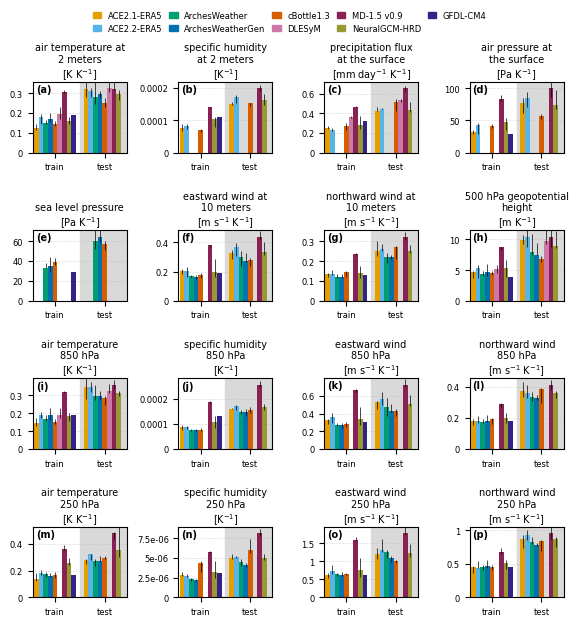

In [8]:
# Appendix Figure: ENSO coefficient RMSE bar chart — surface vars + 850/250 hPa
# GRID matches E1 exactly. zg has no plev dim in the RMSE dataset (pre-selected at 500 hPa).

UNIT_CONVERSIONS = {
    'pr': (86400., r'mm day$^{-1}$ K$^{-1}$'),
}

GRID = [
    [('tas', None), ('huss', None), ('pr', None),   ('ps', None)  ],
    [('psl', None), ('uas', None),  ('vas', None),  ('zg', None)  ],
    [('ta', 85000.),('hus', 85000.),('ua', 85000.), ('va', 85000.)],
    [('ta', 25000.),('hus', 25000.),('ua', 25000.), ('va', 25000.)],
]
NROWS, NCOLS = len(GRID), len(GRID[0])

fig_width  = GMD_DOUBLE_COL_IN
fig_height = min(NROWS * 1.9 + 0.6, GMD_MAX_HEIGHT_IN)
fig, axes  = plt.subplots(
    nrows=NROWS, ncols=NCOLS,
    figsize=(fig_width, fig_height),
    gridspec_kw={'wspace': 0.55, 'hspace': 1.1},
)
fig.subplots_adjust(top=0.88)

_tick_fmt      = mticker.FuncFormatter(lambda x, _: f'{x:g}')
legend_handles = None
panel_letter   = ord('a')

for r, row in enumerate(GRID):
    for c, spec in enumerate(row):
        ax = axes[r, c]

        if spec is None:
            ax.set_axis_off()
            continue

        varname, plev = spec
        letter = chr(panel_letter)
        panel_letter += 1

        if varname not in enso_coeff_rmse_1deg:
            ax.set_axis_off()
            continue

        if plev is not None:
            da = enso_coeff_rmse_1deg[varname].sel(plev=plev, method='nearest').drop_vars('plev')
        else:
            da = enso_coeff_rmse_1deg[varname]

        da      = da.sel(time_period=['training', 'test']).transpose('time_period', 'experiment_submission', 'realization')
        lowest  = da.min('realization').to_dataframe().unstack()
        median  = da.median('realization').to_dataframe().unstack()
        highest = da.max('realization').to_dataframe().unstack()

        units = fmt_units(enso_coeff_rmse_1deg[varname].attrs.get('units', '-'))
        if varname in UNIT_CONVERSIONS:
            scale, units = UNIT_CONVERSIONS[varname]
            lowest  = lowest  * scale
            median  = median  * scale
            highest = highest * scale

        median.plot.bar(width=0.85, 
            ax=ax,
            legend=False,
            color=CATEGORICAL_COLORS,
            yerr=np.concat(
                [(median - lowest).values.T[:, None, :],
                 (highest - median).values.T[:, None, :]],
                axis=1,
            ),
            capsize=0,
            error_kw=dict(elinewidth=0.5),
        )
        if legend_handles is None:
            legend_handles, _ = ax.get_legend_handles_labels()

        ymax = median.max().max()
        ax.set_ylim([0, ymax * 1.1])
        ax.set_axisbelow(True)
        ax.set_xlim(-0.45, 1.45)
        xlim, ylim = ax.get_xlim(), ax.get_ylim()
        mid = (xlim[0] + xlim[1]) / 2
        ax.fill_between(
            [mid, xlim[1]], [0, 0], [ylim[1], ylim[1]],
            color='#d9d9d9', zorder=-2,
        )
        ax.set_xticklabels(['train', 'test'], rotation=0, fontsize=LABEL_FS - 1)
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.yaxis.set_major_formatter(_tick_fmt)
        ax.tick_params(axis='y', labelsize=LABEL_FS - 1)
        ax.yaxis.grid(True, linestyle=':', linewidth=0.4, color='#b3b3b3')

        ax.text(0.03, 0.97, f'({letter})', transform=ax.transAxes,
                fontsize=LABEL_FS, fontweight='bold', va='top', ha='left', zorder=5)

        # Strip the "enso coefficient" suffix the attrs append to long_names
        long_name = (enso_coeff_rmse_1deg[varname].attrs.get('long_name', varname)
                     .replace('_', ' ').lower()
                     .replace(' enso coefficient', ''))
        if varname == 'zg':
            long_name = textwrap.fill(f'500 hPa {long_name}', width=22)
        else:
            long_name = textwrap.fill(long_name, width=18)
        if plev is not None:
            plev_hpa = int(plev / 100)
            title = f'{long_name}\n{plev_hpa} hPa\n[{units}]'
        else:
            title = f'{long_name}\n[{units}]'
        ax.set_title(title, fontsize=LABEL_FS, pad=2)

exp_names_bar = list(enso_coeff_rmse_1deg.experiment_submission.values)
bar_handles = [plt.Rectangle((0, 0), 1, 1, color=CATEGORICAL_COLORS[i])
               for i in range(len(exp_names_bar))]
fig.legend(
    bar_handles,
    exp_names_bar,
    fontsize=LABEL_FS - 1,
    loc='upper center',
    ncol=min(len(exp_names_bar), 5),
    bbox_to_anchor=(0.5, 0.995),
    frameon=False,
    borderpad=0.2,
    columnspacing=0.8,
    handlelength=1.0,
)

fig.patch.set_alpha(0.0)
ms_savefig(fig, 'app_enso_coeff_rmse_bar')
plt.show()

Saved ./figures/manuscript_figures/app_enso_coeff_map_2p8deg.eps


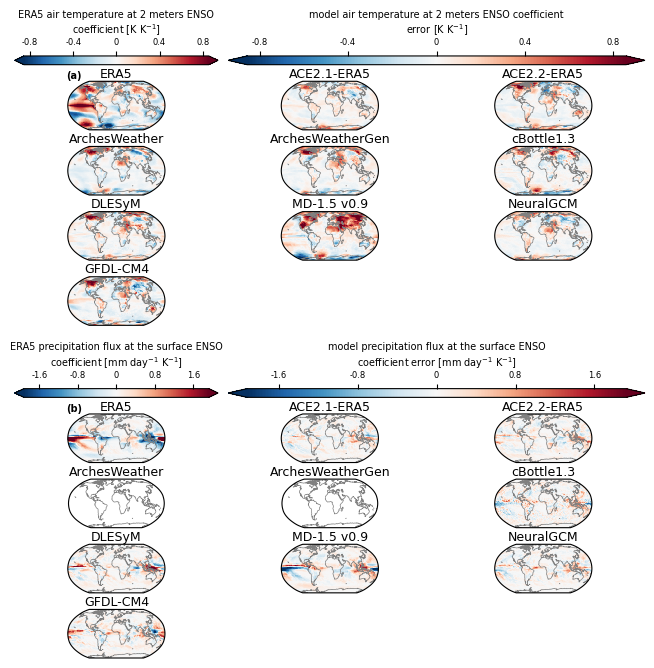

In [9]:
# Appendix Figure: ENSO coefficient error map at 2.8° resolution (NeuralGCM included)
plot_enso_coeff_map(enso_coeff_error_2p8deg, regridded_2p8deg_enso_coeff_era5, '2p8deg', save_name='app_enso_coeff_map_2p8deg')

Saved ./figures/manuscript_figures/app_enso_coeff_rmse_2p8deg_bar.eps


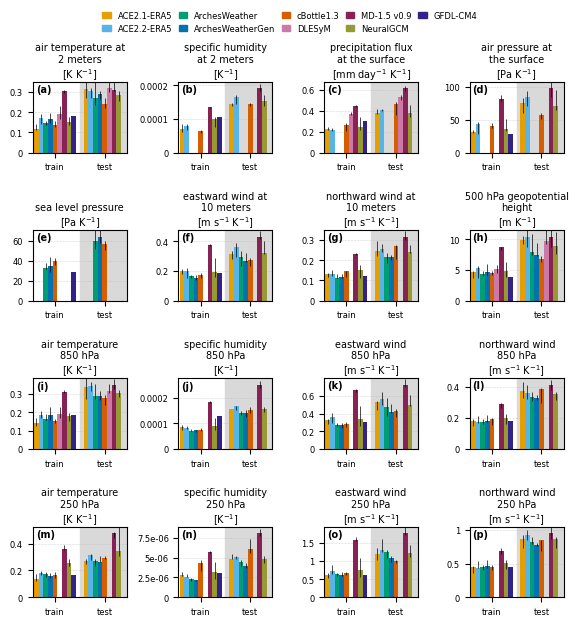

In [10]:
# Appendix Figure: ENSO coefficient RMSE bar chart at 2.8° resolution (NeuralGCM included)
# Mirrors the 1° manuscript bar; data swapped to enso_coeff_rmse_2p8deg.

UNIT_CONVERSIONS = {
    'pr': (86400., r'mm day$^{-1}$ K$^{-1}$'),
}

GRID = [
    [('tas', None), ('huss', None), ('pr', None),   ('ps', None)  ],
    [('psl', None), ('uas', None),  ('vas', None),  ('zg', None)  ],
    [('ta', 85000.),('hus', 85000.),('ua', 85000.), ('va', 85000.)],
    [('ta', 25000.),('hus', 25000.),('ua', 25000.), ('va', 25000.)],
]
NROWS, NCOLS = len(GRID), len(GRID[0])

fig_width  = GMD_DOUBLE_COL_IN
fig_height = min(NROWS * 1.9 + 0.6, GMD_MAX_HEIGHT_IN)
fig, axes  = plt.subplots(
    nrows=NROWS, ncols=NCOLS,
    figsize=(fig_width, fig_height),
    gridspec_kw={'wspace': 0.55, 'hspace': 1.1},
)
fig.subplots_adjust(top=0.88)

_tick_fmt      = mticker.FuncFormatter(lambda x, _: f'{x:g}')
legend_handles = None
panel_letter   = ord('a')

for r, row in enumerate(GRID):
    for c, spec in enumerate(row):
        ax = axes[r, c]

        if spec is None:
            ax.set_axis_off()
            continue

        varname, plev = spec
        letter = chr(panel_letter)
        panel_letter += 1

        if varname not in enso_coeff_rmse_2p8deg:
            ax.set_axis_off()
            continue

        if plev is not None:
            da = enso_coeff_rmse_2p8deg[varname].sel(plev=plev, method='nearest').drop_vars('plev')
        else:
            da = enso_coeff_rmse_2p8deg[varname]

        da      = da.sel(time_period=['training', 'test']).transpose('time_period', 'experiment_submission', 'realization')
        lowest  = da.min('realization').to_dataframe().unstack()
        median  = da.median('realization').to_dataframe().unstack()
        highest = da.max('realization').to_dataframe().unstack()

        units = fmt_units(enso_coeff_rmse_2p8deg[varname].attrs.get('units', '-'))
        if varname in UNIT_CONVERSIONS:
            scale, units = UNIT_CONVERSIONS[varname]
            lowest  = lowest  * scale
            median  = median  * scale
            highest = highest * scale

        median.plot.bar(width=0.85, 
            ax=ax,
            legend=False,
            color=CATEGORICAL_COLORS,
            yerr=np.concat(
                [(median - lowest).values.T[:, None, :],
                 (highest - median).values.T[:, None, :]],
                axis=1,
            ),
            capsize=0,
            error_kw=dict(elinewidth=0.5),
        )
        if legend_handles is None:
            legend_handles, _ = ax.get_legend_handles_labels()

        ymax = median.max().max()
        ax.set_ylim([0, ymax * 1.1])
        ax.set_axisbelow(True)
        ax.set_xlim(-0.45, 1.45)
        xlim, ylim = ax.get_xlim(), ax.get_ylim()
        mid = (xlim[0] + xlim[1]) / 2
        ax.fill_between(
            [mid, xlim[1]], [0, 0], [ylim[1], ylim[1]],
            color='#d9d9d9', zorder=-2,
        )
        ax.set_xticklabels(['train', 'test'], rotation=0, fontsize=LABEL_FS - 1)
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.yaxis.set_major_formatter(_tick_fmt)
        ax.tick_params(axis='y', labelsize=LABEL_FS - 1)
        ax.yaxis.grid(True, linestyle=':', linewidth=0.4, color='#b3b3b3')

        ax.text(0.03, 0.97, f'({letter})', transform=ax.transAxes,
                fontsize=LABEL_FS, fontweight='bold', va='top', ha='left', zorder=5)

        long_name = (enso_coeff_rmse_2p8deg[varname].attrs.get('long_name', varname)
                     .replace('_', ' ').lower()
                     .replace(' enso coefficient', ''))
        if varname == 'zg':
            long_name = textwrap.fill(f'500 hPa {long_name}', width=22)
        else:
            long_name = textwrap.fill(long_name, width=18)
        if plev is not None:
            plev_hpa = int(plev / 100)
            title = f'{long_name}\n{plev_hpa} hPa\n[{units}]'
        else:
            title = f'{long_name}\n[{units}]'
        ax.set_title(title, fontsize=LABEL_FS, pad=2)

exp_names_bar = list(enso_coeff_rmse_2p8deg.experiment_submission.values)
bar_handles = [plt.Rectangle((0, 0), 1, 1, color=CATEGORICAL_COLORS[i])
               for i in range(len(exp_names_bar))]
fig.legend(
    bar_handles,
    exp_names_bar,
    fontsize=LABEL_FS - 1,
    loc='upper center',
    ncol=min(len(exp_names_bar), 5),
    bbox_to_anchor=(0.5, 0.995),
    frameon=False,
    borderpad=0.2,
    columnspacing=0.8,
    handlelength=1.0,
)

fig.patch.set_alpha(0.0)
ms_savefig(fig, 'app_enso_coeff_rmse_2p8deg_bar')
plt.show()